# Прогнозирование временного ряда

**Датасет:** Monthly Air Passengers (1949–1960) — месячное число пассажиров авиакомпаний.


In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from gplearn.genetic import SymbolicRegressor
import gmdh

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

## Загрузка и визуализация

In [6]:
#URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv('data.csv', parse_dates=['Month'])
df = df.rename(columns={'Month': 'date', 'Passengers': 'value'})
df = df.set_index('date')
series = df['value']
print(f'Размер ряда: {len(series)}, период: {series.index[0].date()} — {series.index[-1].date()}')
df.head()

Размер ряда: 144, период: 1949-01-01 — 1960-12-01


,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


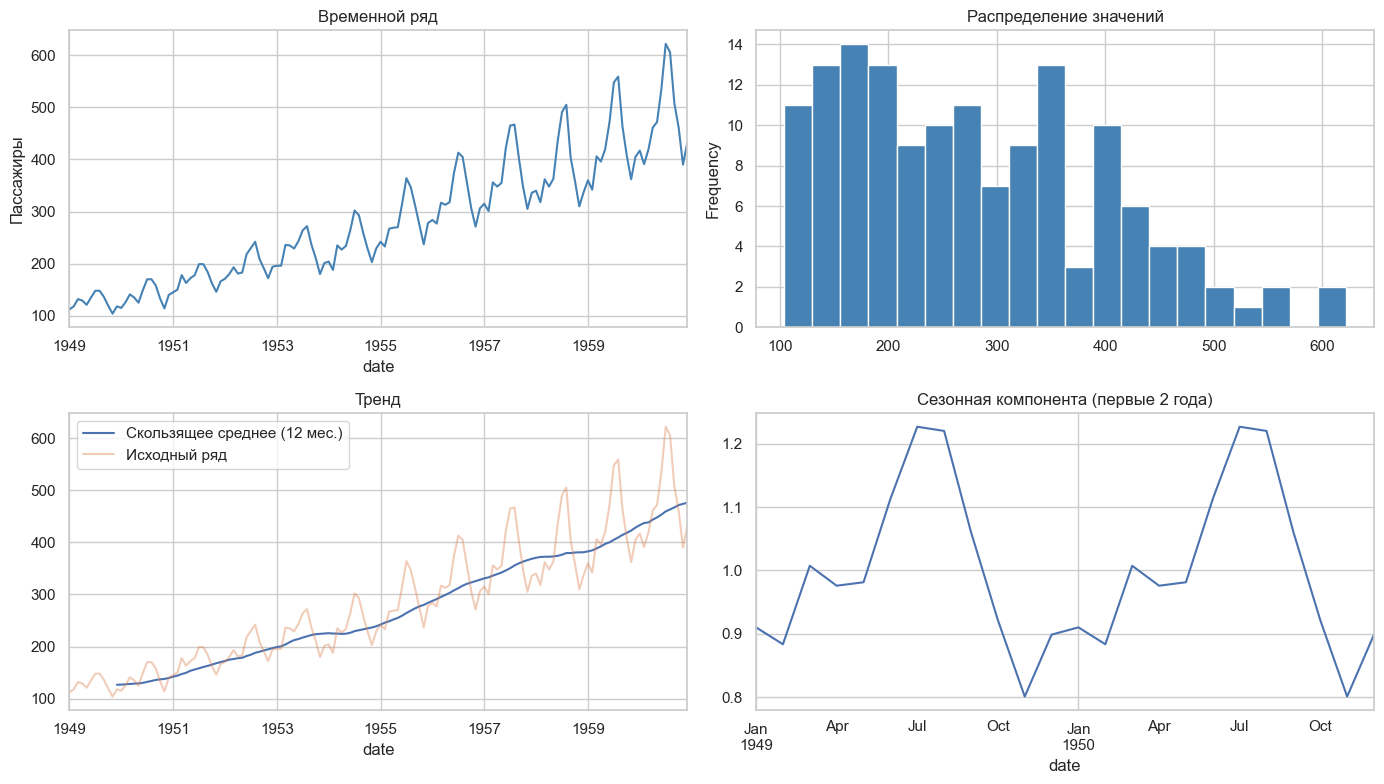

Среднее: 280.3, std: 120.0, min: 104, max: 622


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

series.plot(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Временной ряд')
axes[0, 0].set_ylabel('Пассажиры')

series.plot.hist(bins=20, ax=axes[0, 1], color='steelblue', edgecolor='white')
axes[0, 1].set_title('Распределение значений')

series.rolling(12).mean().plot(ax=axes[1, 0], label='Скользящее среднее (12 мес.)')
series.plot(ax=axes[1, 0], alpha=0.4, label='Исходный ряд')
axes[1, 0].legend()
axes[1, 0].set_title('Тренд')

decomp = seasonal_decompose(series, model='multiplicative', period=12)
decomp.seasonal[:24].plot(ax=axes[1, 1])
axes[1, 1].set_title('Сезонная компонента (первые 2 года)')

plt.tight_layout()
plt.show()

print(f'Среднее: {series.mean():.1f}, std: {series.std():.1f}, min: {series.min()}, max: {series.max()}')

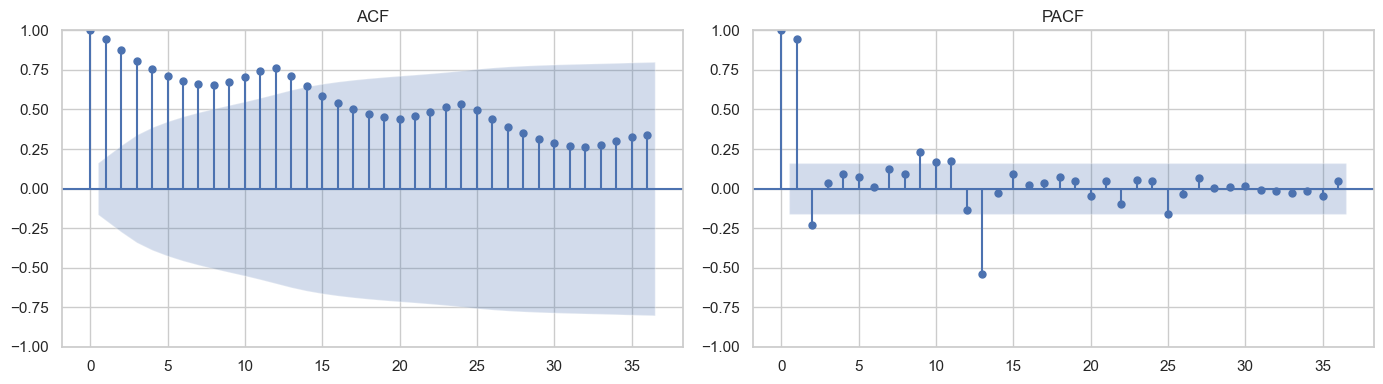

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=36, ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(series, lags=36, ax=axes[1])
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

## Разбиение на обучающую и тестовую выборки

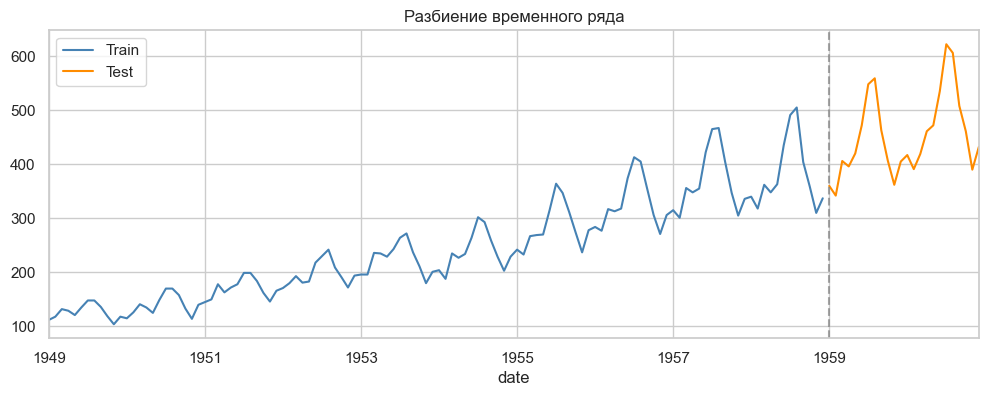

Train: 120 точек, Test: 24 точек


In [9]:
TEST_SIZE = 24
LAGS = 12

train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

fig, ax = plt.subplots(figsize=(12, 4))
train.plot(ax=ax, label='Train', color='steelblue')
test.plot(ax=ax, label='Test', color='darkorange')
ax.axvline(test.index[0], color='gray', linestyle='--', alpha=0.7)
ax.legend()
ax.set_title('Разбиение временного ряда')
plt.show()

print(f'Train: {len(train)} точек, Test: {len(test)} точек')

In [10]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

def plot_forecast(y_true, y_pred, title, index):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(index, y_true, 'o-', label='Факт', color='black')
    ax.plot(index, y_pred, 's--', label='Прогноз', color='crimson')
    ax.set_title(title)
    ax.legend()
    plt.show()

## ARIMA (SARIMA)

{'RMSE': 73.45467492891336, 'MAE': 67.58761665632956, 'MAPE (%)': 14.695661652738984}


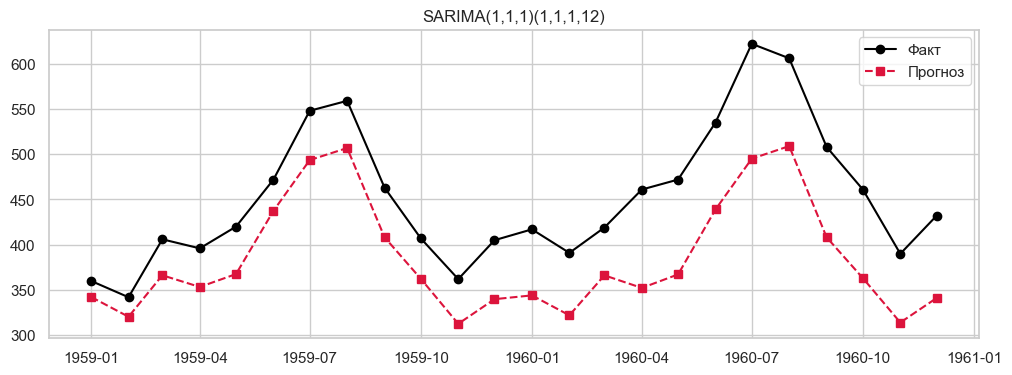

In [11]:
model_arima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
result_arima = model_arima.fit(disp=False)
pred_arima = result_arima.forecast(TEST_SIZE)

metrics_arima = calc_metrics(test.values, pred_arima)
print(metrics_arima)
plot_forecast(test.values, pred_arima, 'SARIMA(1,1,1)(1,1,1,12)', test.index)

## Символьная регрессия (gplearn)

Найденное выражение: add(div(sub(X11, mul(-0.092, add(sub(mul(-0.092, sub(add(X11, sub(sub(X11, mul(-0.092, add(X11, div(X2, X1)))), mul(-0.092, add(X11, sub(sub(X11, -0.121), div(X2, X1)))))), -0.692)), -0.692), sub(X11, mul(-0.092, mul(0.182, X6)))))), X1), sub(X0, mul(-0.092, add(X11, sub(X11, sub(X0, mul(-0.092, mul(-0.092, mul(-0.092, X1)))))))))
{'RMSE': 15.854522510297306, 'MAE': 13.23620474032527, 'MAPE (%)': 2.9580166990831613}


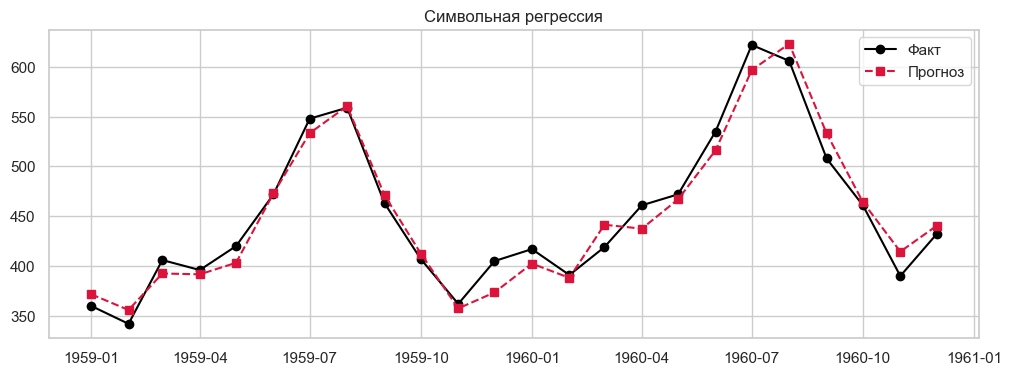

In [12]:
def make_lag_matrix(ts, lags):
    X, y = [], []
    for i in range(lags, len(ts)):
        X.append(ts[i - lags:i])
        y.append(ts[i])
    return np.array(X), np.array(y)

values = series.values.astype(float)
X_all, y_all = make_lag_matrix(values, LAGS)
n_train = len(train) - LAGS

X_tr_sym, y_tr_sym = X_all[:n_train], y_all[:n_train]
X_te_sym, y_te_sym = X_all[n_train:], y_all[n_train:]

sym_model = SymbolicRegressor(
    population_size=1000,
    generations=30,
    tournament_size=20,
    stopping_criteria=0.01,
    parsimony_coefficient=0.001,
    max_samples=0.9,
    random_state=42,
    verbose=0,
)
sym_model.fit(X_tr_sym, y_tr_sym)
pred_sym = sym_model.predict(X_te_sym)

print('Найденное выражение:', sym_model._program)
metrics_sym = calc_metrics(y_te_sym, pred_sym)
print(metrics_sym)
plot_forecast(y_te_sym, pred_sym, 'Символьная регрессия', test.index)

## МГУА: COMBI (линейный) и MIA (нелинейный)

COMBI: y = 0.6389*x1 + 0.1583*x2 - 0.1069*x3 - 0.0734*x11 + 0.3996*x12 + 13.064
{'RMSE': 23.4464193764497, 'MAE': 19.821874912422786, 'MAPE (%)': 4.359717970100016}


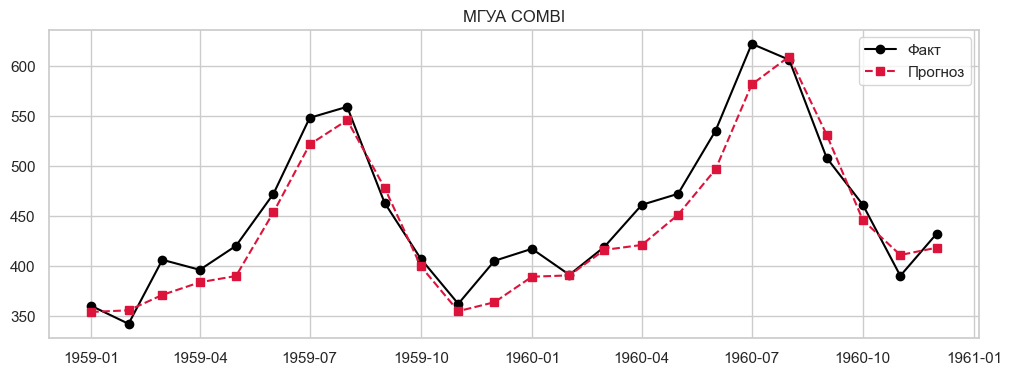

In [13]:
X_gmdh, y_gmdh = gmdh.time_series_transformation(values.tolist(), LAGS)
X_tr_g, y_tr_g = X_gmdh[:n_train], y_gmdh[:n_train]
X_te_g = X_gmdh[n_train:]

model_combi = gmdh.Combi()
model_combi.fit(X_tr_g, y_tr_g)
pred_combi = model_combi.predict(X_te_g)

print('COMBI:', model_combi.get_best_polynomial())
metrics_combi = calc_metrics(test.values, pred_combi)
print(metrics_combi)
plot_forecast(test.values, pred_combi, 'МГУА COMBI', test.index)

MIA: f1_1 = 0.5695*x3 + 0.633*x12 - 0.0012*x3*x12 - 0.0001*x3^2 + 0.0007*x12^2 - 8.252
f1_2 = 0.3335*x5 + 0.9293*x12 - 0.0084*x5*x12 + 0.0038*x5^2 + 0.0035*x12^2 - 10.6973

y = 0.7298*f1_1 + 0.2851*f1_2 - 0.063*f1_1*f1_2 + 0.0314*f1_1^2 + 0.0316*f1_2^2 - 2.2789
{'RMSE': 62.9931335651827, 'MAE': 49.12062250808225, 'MAPE (%)': 10.547862547294722}


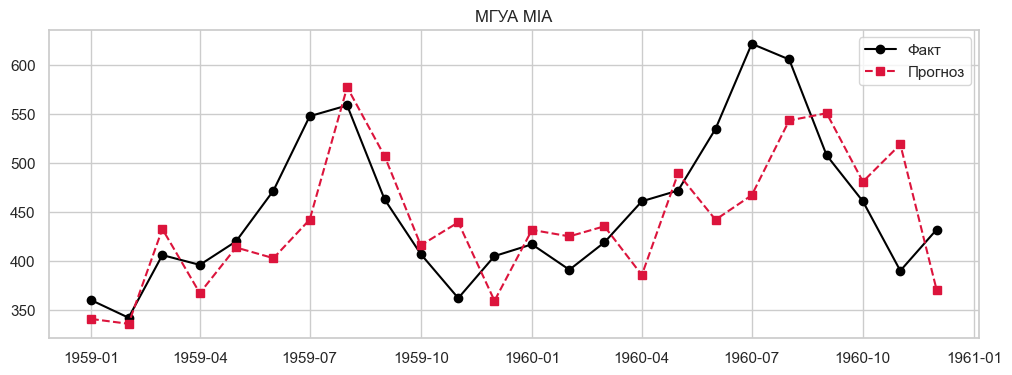

In [14]:
model_mia = gmdh.Mia()
model_mia.fit(X_tr_g, y_tr_g)
pred_mia = model_mia.predict(X_te_g)

print('MIA:', model_mia.get_best_polynomial())
metrics_mia = calc_metrics(test.values, pred_mia)
print(metrics_mia)
plot_forecast(test.values, pred_mia, 'МГУА MIA', test.index)

## Сравнение метрик

In [15]:
results = pd.DataFrame([
    {'Модель': 'SARIMA', **metrics_arima},
    {'Модель': 'Символьная регрессия', **metrics_sym},
    {'Модель': 'COMBI', **metrics_combi},
    {'Модель': 'MIA', **metrics_mia},
]).set_index('Модель')
results

,RMSE,MAE,MAPE (%)
Модель,,,
SARIMA,73.454675,67.587617,14.695662
Символьная регрессия,15.854523,13.236205,2.958017
COMBI,23.446419,19.821875,4.359718
MIA,62.993134,49.120623,10.547863


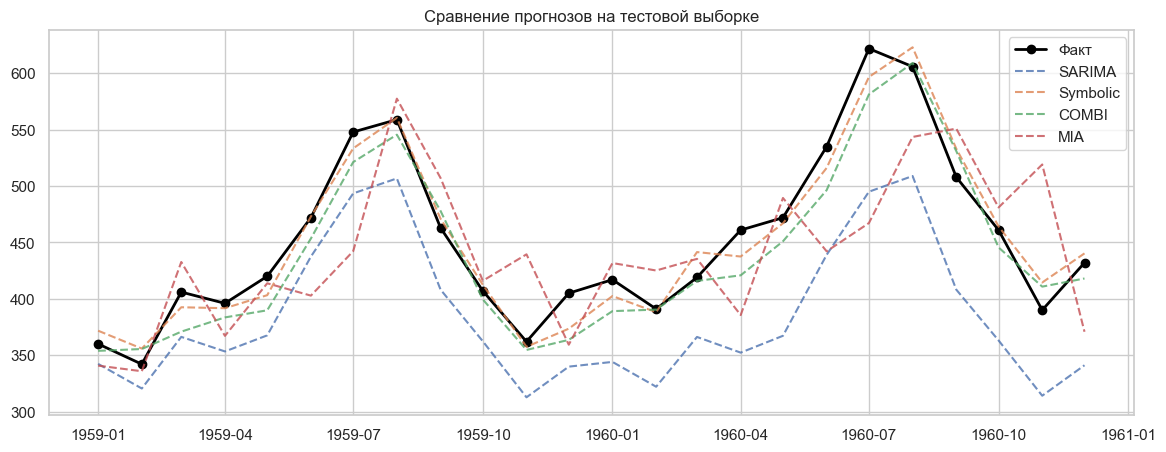

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values, 'o-', color='black', linewidth=2, label='Факт')

forecasts = {
    'SARIMA': pred_arima,
    'Symbolic': pred_sym,
    'COMBI': pred_combi,
    'MIA': pred_mia,
}
for name, pred in forecasts.items():
    ax.plot(test.index, pred, '--', alpha=0.8, label=name)

ax.set_title('Сравнение прогнозов на тестовой выборке')
ax.legend()
plt.show()